In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import math
import pandas as pd

plt.rcParams['text.usetex'] = True

from utils import *

## Model definition

In [2]:
N1 = 500
N2 = 500

N = N1+N2

DeltaE = 0.5

deltae = 0.5
lam = 5e-4

Nt = 1000
dt = 3

In [3]:
gamma_1 = 2*np.pi*lam**2*N1/deltae
gamma_2 = 2*np.pi*lam**2*N2/deltae

gamma = gamma_1+gamma_2
print(gamma)

0.003141592653589793


In [4]:
# H_0 = np.kron(Z(), np.eye(N)) 

# for n1 in range(N1):
#     H_0 = H_0 + deltae/N1*n1*np.kron(np.eye(2),ketbra(n1,n1,N))

# for n2 in range(N2):
#     H_0 = H_0 + deltae/N2*(N1+n2)*np.kron(np.eye(2),ketbra(N1+n2,N1+n2,N)) 
#     #(DeltaE + deltae/N2*(N1+n2))*np.kron(np.eye(2),ketbra(N1+n2,N1+n2,N))

# C = (np.random.randn(N1*N2)+1j*np.random.randn(N1*N2)).reshape([N1,N2])  
# cc = 0
# for n1 in range(N1):
#     for n2 in range(N2):
#         cc += np.abs(C[n1,n2])**2/(N1*N2) 
# C = C/np.sqrt(cc)

# B = np.zeros([N,N])

# for n1 in range(N1):
#     for n2 in range(N2):
#         A = C[n1,n2]*ketbra(n1,N1+n2,N)
#         B = B + A + A.H

# H_int = lam* np.kron(X(),B)

# H = H_0 + H_int

# plot_matrix(H)

In [5]:
# rho_E = np.zeros([N,N])
# for n1 in range(N1):
#     rho_E = rho_E + ketbra(n1,n1,N)/N1
# #rho_0 = np.kron(np.ones([2,2])/2,rho_E)
# rho_0 = np.kron(ketbra(1,1,2),rho_E)

# plot_matrix(rho_0)

## Simulation

In [6]:
ts = np.arange(Nt+1)*dt

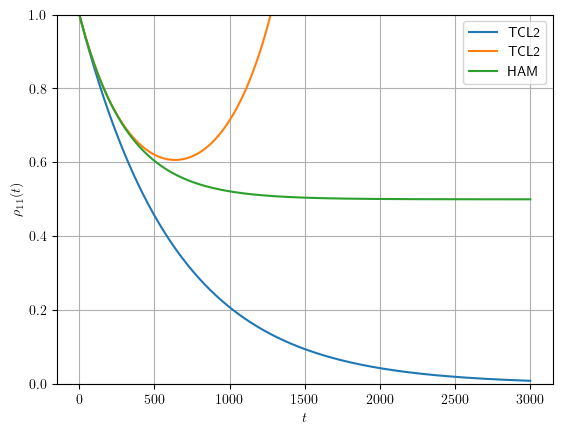

In [7]:
plt.figure()
plt.plot(ts,np.exp(-gamma_2*ts),label='TCL2')
plt.plot(ts,np.exp(-gamma_2*ts+gamma_1*gamma_2*ts**2/2),label='TCL2')
plt.plot(ts,gamma_1/gamma + gamma_2/gamma * np.exp(-gamma*ts),label='HAM')
plt.grid()
plt.ylabel(r'$\rho_{11}(t)$')
plt.xlabel('$t$')
plt.ylim([0,1])
plt.legend()
plt.show()


In [ ]:
S0 = DeltaE*Z()
S1 = np.eye(2)
S2 = (X()+1j*Y())/2
S3 = (X()-1j*Y())/2

E0 = np.eye(N)
E1 = np.zeros_like(E0)
for n1 in range(N1):
    E1 = E1 + deltae/N1*n1*ketbra(n1,n1,N)
for n2 in range(N2):
    E1 = E1 + deltae/N2*(N1+n2)*ketbra(N1+n2,N1+n2,N)

# E2 = 0
# E3 = E2.H

AttributeError: 'int' object has no attribute 'H'